# CSP571 Graded Assignment: Part 1 and Part 2

## Introduction

This notebook contains two related data preparation and exploratory analysis exercises for CSP571.

**Part 1** analyzes employee salary data from `EmployeePositionRoster_06302023.xls`. The goal is to focus on teachers, summarize their annual salaries, evaluate several candidate histogram bin widths with the Shimazaki and Shinomoto criterion, and visualize the salary distribution using the best bin width that satisfies the assignment constraints.

**Part 2** analyzes transaction-level retail data from `Online_Retail.csv`. The goal is to prepare customer-level Recency, Frequency, and Monetary (RFM) features, assign quintile-based RFM scores, summarize customer segment sizes, and visualize patterns with bar charts, a heatmap, and boxplots.

The notebook is organized as a reproducible workflow: load data, clean or transform fields, compute summary features, inspect intermediate results, and produce visualizations that support interpretation.

## High Level Procedure

1. Import Python libraries used for data analysis and plotting.
2. Load and inspect the employee roster data.
3. Filter the roster to teachers and summarize annual salary.
4. Implement helper functions for descriptive statistics and histogram bin-width selection.
5. Compare candidate salary histogram bin widths and plot the selected histogram.
6. Load and inspect online retail transaction data.
7. Build customer-level RFM measures.
8. Convert RFM measures into quintile scores and an overall RFM score.
9. Visualize customer score distributions and high-value customer behavior.


## Part 1: Teacher Salary Distribution

Part 1 studies the annual salary distribution for employees whose classification indicator is `T`, which represents teachers. The main analytical question is how to construct a useful histogram for annual salaries.

Because histograms can look very different depending on bin width, this part compares several candidate bin widths and uses the Shimazaki and Shinomoto criterion to choose a reasonable bin width from the assignment-approved range.


### Import Required Libraries

This cell imports the core packages used throughout the notebook:

- `pandas` for tabular data loading, filtering, grouping, and reshaping.
- `numpy` for numerical calculations such as ranges, means, and quantiles.
- `matplotlib.pyplot` for plotting histograms and other visualizations.


In [2]:
# Import Common Packages for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Employee Roster

The employee roster is loaded from the Excel file `EmployeePositionRoster_06302023.xls`. This dataset is the source for the salary analysis in Part 1.

After loading, the dataframe `df` contains all employee records, not only teachers.


In [3]:
# Load the dataset from xls file
df = pd.read_excel('EmployeePositionRoster_06302023.xls')

### Inspect the Raw Data

Displaying the first few rows helps verify that the file loaded correctly and lets us identify relevant columns such as `ClsIndc` and `Annual Salary`.


In [4]:
# Inspect the dataset
df.head()

,Pos #,Dept ID,Department,FTE,ClsIndc,Annual Salary,FTE Annual Salary,Annual Benefit Cost,JobCode,Job Title,Name
0,111427,49021,Northside Learning Center,1.0,T,108686.0,108686.0,34356.0,500629,Special Education Teacher,"Miller, Hope"
1,111428,11675,Diverse Lrn Related Svc Prv CW,1.0,T,92701.0,92701.0,30798.0,984100,School Social Worker,"Gunn, Monique N"
2,111436,23131,Esmond School,1.0,T,110607.0,110607.0,34784.0,49,Regular Teacher,"Jeff, Lisa Y"
3,111441,23911,Edward N Hurley School,1.0,T,102062.0,102062.0,32882.0,55,Bilingual Teacher,"Segura, Amalia"
4,111445,47061,Senn HS,1.0,T,81947.0,81947.0,28404.0,500629,Special Education Teacher,"Stankiewicz, Kevin G"


### Filter to Teachers and Summarize Salary

This cell creates `df_teachers` by keeping only records where `ClsIndc == 'T'`. It then uses `.describe()` to produce a quick five-number-style summary of `Annual Salary`, including count, mean, standard deviation, minimum, quartiles, and maximum.

This summary provides the salary range needed for later histogram bin construction.


In [5]:
# Select ClsIndc = 'T' (for teachers only) and create a new dataframe.
df_teachers = df[df['ClsIndc'] == 'T']

# Get the five-number summary for the column labeled "Annual Salary" in the new dataframe.
df_teachers['Annual Salary'].describe()

count     23791.000000
mean      91685.174310
std       20683.266795
min           0.000000
25%       76017.000000
50%       92701.000000
75%      105317.000000
max      265000.000000
Name: Annual Salary, dtype: float64

### Helper Function: Basic Univariate Statistics

The `univariate()` function computes four statistics from first principles:

- Number of valid, non-missing observations.
- Minimum value.
- Maximum value.
- Arithmetic mean.

The function is later reused by the histogram bin-width procedure so that the bin boundaries can be based on the salary range and mean.


In [6]:
# Create a helper function to calculate the four different descriptive statistics for a Pandas Series.

def univariate (y):
    ''' Compute four descriptive statistics from first principles.

    Argument:
    ---------
    y : a Pandas Series of numeric values
    
    Output:
    -------
    y_nvalid : number of non-NaN values
    y_min : the minimum value
    y_max : the maximum value
    y_mean : the arithmetic mean

    '''
    # Initialize
    y_nvalid = 0
    y_min = None
    y_max = None
    y_sum = None

    # Loop through all values in the series
    for u in y:
        if (not np.isnan(u)):
            y_nvalid += 1

            if (y_min is not None):
                if (u < y_min):
                    y_min = u
            else:
                y_min = u
        
            if (y_max is not None):
                if (u > y_max):
                    y_max = u
            else:
                y_max = u
            
            if (y_sum is not None):
                y_sum += u
            else:
                y_sum = u
    
    # Finalize
    if (y_nvalid > 0):
        y_mean = y_sum / y_nvalid
    
    return (y_nvalid, y_min, y_max, y_mean)


### Helper Function: Shimazaki and Shinomoto Criterion

The `shimazaki_criterion()` function evaluates candidate histogram bin widths. For each bin width, it:

- Centers bins around the approximate mean of the data.
- Computes the number of bins needed to cover the observed range.
- Builds bin boundaries.
- Counts observations in each bin.
- Computes the Shimazaki and Shinomoto criterion.

Lower criterion values indicate a better candidate bin width under this method. The function returns the number of bins, the bin boundaries, and the criterion value for each candidate width.

Annotation: when constructing bin boundaries, the boundary should advance by one bin width each loop iteration. A repeated boundary would create invalid zero-width bins for plotting.


In [7]:
# Create a helper function to calculate the Shimazaki and Shinomoto criterion.

def shimazaki_criterion (y, d_list):
    '''Compute the criterion based on the Shimazaki and Shinomoto (2007) paper

    Argument:
    ---------------
    y: a Pandas Series of numerical values 
    d_list: a list of candidates of bin-widths

    Output:
    -----------
    number_bins: a list of number of bins (length is same as d_list)
    matrix_boundary: a list of bin boundaries, each element is a list
    criterion_list: a list of criterion values

    '''

    number_bins = []
    matrix_boundary = []
    criterion_list = []

    y_nvalid, y_min, y_max, y_mean = univariate (y)

    if (y_nvalid <= 0):
        raise ValueError('There are no non-missing values in the data vector.')
    else:
        # Loop through the bin width candidates
        for delta in d_list:
            y_middle = delta * np.round(y_mean / delta)
            n_bin_left = np.ceil((y_middle - y_min) / delta)
            n_bin_right = np.ceil((y_max - y_middle) / delta)
            y_low = y_middle - n_bin_left * delta

            # Assign observations to each bin starting from 0
            list_boundary = []
            n_bin = n_bin_left + n_bin_right
            bin_index = 0
            bin_boundary = y_low
            for i in np.arange(n_bin):
                bin_boundary += delta
                bin_index = np.where(y > bin_boundary, i+1, bin_index)
                list_boundary.append(bin_boundary)
            
            # Count the number of observations in each bins
            uvalue, ucount = np.unique(bin_index, return_counts = True)

            # Calculate Shimazaki and Shinomoto criterion
            mean_ucount = np.mean(ucount)
            variance_ucount = np.mean(np.power((ucount- mean_ucount), 2))
            criterion = ( 2 * mean_ucount - variance_ucount)/np.power(delta,2)

            number_bins.append(n_bin)
            matrix_boundary.append(list_boundary)
            criterion_list.append(criterion)
    
    return(number_bins, matrix_boundary, criterion_list)

### Evaluate Candidate Bin Widths

The assignment considers bin widths based on the multipliers `1.0`, `1.25`, `2.0`, `2.5`, and `5.0` at powers of 10. This produces candidate widths such as 1,000, 1,250, 2,000, and so on.

The function is then applied to teacher annual salaries so each candidate width can be compared.


In [8]:
#  Calculation based on df_teachers

d_list = []
d0_list = [1.0, 1.25, 2.0, 2.5, 5.0]

for p in [3, 4]:
    d_list.extend( u * np.power(10, p) for u in d0_list)

#type(d_list[0])

number_bins, matrix_boundary, criterion_list = shimazaki_criterion(df_teachers['Annual Salary'], d_list)

### Tabulate Bin-Width Results

The candidate bin widths, number of bins, and criterion values are combined into `result_df`. This table makes it easier to compare alternatives and identify which bin width has the lowest criterion.


In [9]:
# Tabulate the results in a Pandas DataFrame
result_df = pd.DataFrame(columns = ['Bin_width', 'N Bin', 'Criterion'])
result_df['Bin_width'] = d_list
result_df['N Bin'] = number_bins
result_df['Criterion'] = criterion_list

result_df.head(len(d_list))

,Bin_width,N Bin,Criterion
0,1000.0,265.0,-0.079809
1,1250.0,212.0,-0.065648
2,2000.0,133.0,-0.052128
3,2500.0,106.0,-0.047095
4,5000.0,53.0,-0.037533
5,10000.0,27.0,-0.029720
6,12500.0,22.0,-0.028956
7,20000.0,14.0,-0.023107
8,25000.0,11.0,-0.017841
9,50000.0,6.0,-0.011301


### Apply Assignment Constraint on Number of Bins

The assignment restricts the acceptable number of bins to between 10 and 50. This cell filters the result table to keep only candidate bin widths that satisfy that requirement.

The final bin-width choice is made from this filtered table rather than from every possible candidate.


In [10]:
# Only Display results with N Bin from 10 to 50, as per the requirement of the assignment.
result_df_filtered = result_df[(result_df['N Bin'] >= 10) & (result_df['N Bin'] <= 50)]
result_df_filtered.head(len(result_df_filtered))

,Bin_width,N Bin,Criterion
5,10000.0,27.0,-0.029720
6,12500.0,22.0,-0.028956
7,20000.0,14.0,-0.023107
8,25000.0,11.0,-0.017841


### Plot the Teacher Salary Histogram

This cell selects the bin width with the smallest criterion value among the allowed candidates and uses its bin boundaries to draw the salary histogram.

Interpretation note: in a histogram of annual salary, the x-axis should represent salary and the y-axis should represent the number of teachers in each salary interval.


The best bin width according to Shimazaki and Shinomoto criterion is: 10000.0


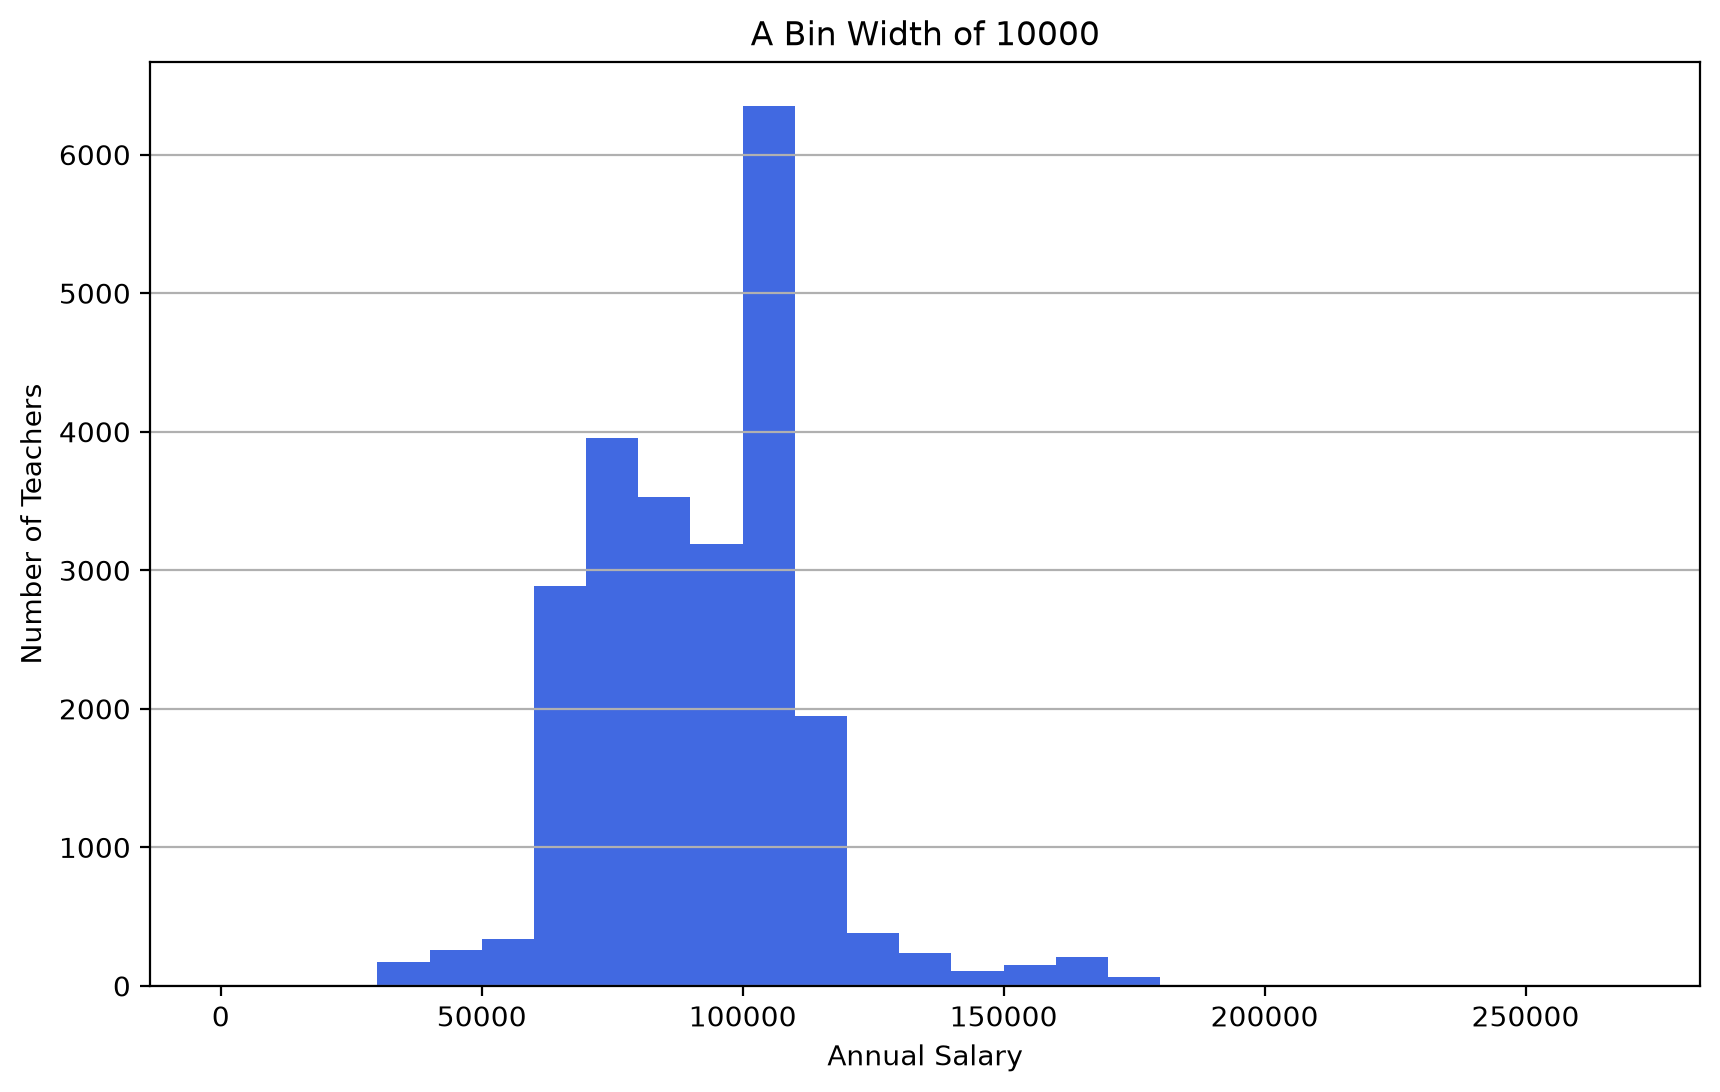

In [11]:
# Based on df_teachers['Annual Salary'], draw histogram for the bin width that minimizes the criterion value.

y_nvalid, y_min, y_max, y_mean = univariate(df_teachers['Annual Salary'])
best_index = result_df_filtered['Criterion'].idxmin()
best_bin_width = result_df_filtered.loc[best_index, 'Bin_width']
print("The best bin width according to Shimazaki and Shinomoto criterion is:", best_bin_width)

# Include the leftmost salary boundary, then use the boundary list for the selected best bin width.
bin_boundary = [y_min] + matrix_boundary[best_index]

plt.figure(figsize=(10, 6), dpi=200)
plt.title(f'A Bin Width of {best_bin_width:.0f}')
plt.hist(df_teachers['Annual Salary'], bins=bin_boundary, color='royalblue')
plt.xlabel('Annual Salary')
plt.ylabel('Number of Teachers')
plt.xticks(np.arange(y_min, y_max + best_bin_width, best_bin_width * 5))
plt.grid(axis='y')
plt.show()


## Part 2: Customer RFM Analysis

Part 2 shifts from employee salary data to retail transaction data. The goal is to summarize transaction records at the customer level using RFM analysis:

- **Recency**: how recently or how late in the observation window the customer purchased.
- **Frequency**: how many unique invoice-stock transactions the customer made.
- **Monetary**: how much total money the customer spent.

These measures are converted into quintile scores so customers can be compared and grouped.


### Load the Online Retail Dataset

The retail dataset is loaded from `Online_Retail.csv`. The encoding is specified because retail datasets often contain special characters in country names, product descriptions, or other text fields.


In [12]:
# Load the dataset for part 2

df_part2 = pd.read_csv('Online_Retail.csv')

### Inspect Retail Records

The first few rows are displayed to confirm that the file loaded correctly and to inspect important columns such as `Invoice`, `StockCode`, `Customer ID`, `Quantity`, `Price`, `InvoiceDate`, and `Country`.


In [13]:
# Inspect the dataset
df_part2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


### Create a Unique Transaction Item Identifier

An invoice can contain multiple stock codes, so the combination of `Invoice` and `StockCode` identifies a unique invoice-item transaction. The new `Invoice_StockCode` column supports the Frequency calculation later in the notebook.


In [14]:
# Invoice + StockCode represents a unique transaction. Create a new column called Invoice_StockCode to represent the unique transaction.
df_part2['Invoice_StockCode'] = df_part2['Invoice'] + '_' + df_part2['StockCode']

# Move the new column to the front of the dataframe
cols = df_part2.columns.tolist()
cols.insert(0, cols.pop(cols.index('Invoice_StockCode')))
df_part2 = df_part2[cols]

# Inspect the dataset again to see the new column
df_part2.head()

,Invoice_StockCode,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434_85048,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434_79323P,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434_79323W,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434_22041,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434_21232,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


### Begin RFM Feature Engineering

This section prepares the retail data for customer-level RFM analysis. The transaction-level data must be rolled up so each customer has one Recency value, one Frequency value, and one Monetary value.


In [15]:
# Start the RFM Analysis based on the dataset in df_part2.

# Get the earliest date as the reference for the recency calculation

# Convert the InvoiceDate column to a number for easier calculation of the recency. 
# The InvoiceDate column is in string format, so we need to convert it to datetime format first.
df_part2['InvoiceDate'] = pd.to_datetime(df_part2['InvoiceDate'], format='%m/%d/%Y %H:%M')

# Then we can get the earliest date in the dataset as the starting date for the recency calculation.
# The refernce date is the earliest date in the dataset minus 1 day.
reference_date = df_part2['InvoiceDate'].min() - pd.Timedelta(days=1)
print("The earliest date in the dataset is:", reference_date)

# Then we can calculate the recency for each unique transaction by subtracting the InvoiceDate from the reference date and converting the result to days.
df_part2['Days'] = (df_part2['InvoiceDate'] - reference_date).dt.days

# Inpsect the dataset again to see the new column
df_part2.head()

The earliest date in the dataset is: 2009-11-30 07:45:00


,Invoice_StockCode,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Days
0,489434_85048,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,1
1,489434_79323P,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,1
2,489434_79323W,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,1
3,489434_22041,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,1
4,489434_21232,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,1


### Calculate Customer Recency

This cell converts invoice dates to chronological units and summarizes them by customer. In this notebook, Recency is represented using the largest chronological value observed for each customer.

That gives each customer a single time-based feature that can be ranked against other customers.


In [16]:
# Roll up the observations to the customer level and calculate Recency as the largest number of chronological units for each customer.
df_recency = df_part2.groupby('Customer ID').agg({'Days': 'max'}).reset_index()
df_recency.rename(columns={"Days": "Recency"}, inplace=True)

# Inspect the dataset to see the recency for each customer
df_recency.head()


,Customer ID,Recency
0,12346.0,414
1,12347.0,700
2,12348.0,664
3,12349.0,721
4,12350.0,429


### Calculate Customer Frequency

Frequency is computed as the number of unique `Invoice_StockCode` values for each customer. This measures how many distinct invoice-item transactions are associated with each customer.


In [17]:
# Roll up the observations to the customer level and calculate Frequency as the number of unique transactions for each customer.
df_frequency = df_part2.groupby('Customer ID').agg({'Invoice_StockCode': 'nunique'}).reset_index()
df_frequency.rename(columns={'Invoice_StockCode': 'Frequency'}, inplace=True)

# Inspect the dataset to see the frequency for each customer
df_frequency.head()

,Customer ID,Frequency
0,12346.0,39
1,12347.0,211
2,12348.0,47
3,12349.0,180
4,12350.0,17


### Calculate Customer Monetary Value

Monetary value is calculated from transaction spending, typically using quantity multiplied by price, then summing to the customer level. This produces the total amount spent by each customer.


In [18]:
# Roll up the observations to the customer level and calculate the sum of amount spent by each customer. The amount spent is calculated as the product of Quantity and UnitPrice for each transaction.
df_part2['AmountSpent'] = df_part2['Quantity'] * df_part2['Price']
df_monetary = df_part2.groupby('Customer ID').agg({'AmountSpent': 'sum'}).reset_index()
df_monetary.rename(columns={'AmountSpent': 'Monetary'}, inplace=True)

# Inspect the dataset to see the monetary value for each customer
df_monetary.head()

,Customer ID,Monetary
0,12346.0,-64.68
1,12347.0,5408.50
2,12348.0,2019.40
3,12349.0,4404.54
4,12350.0,334.40


### Inspect Monetary Values

This inspection step checks the customer-level monetary totals before scoring. It is useful for identifying unusual values, such as zero or negative totals caused by cancellations or returns.


In [19]:
# Inspect the monetary value for each customer. 

# Count how many customers have a negative monetary value, which indicates that they returned more items than they purchased.
negative_monetary_count = df_monetary[df_monetary['Monetary'] < 0].shape[0]
print("Number of customers with negative monetary value:", negative_monetary_count)

# Count how many customers have a zero monetary value, which indicates that they purchased and returned the same amount of items.
zero_monetary_count = df_monetary[df_monetary['Monetary'] == 0].shape[0]
print("Number of customers with zero monetary value:", zero_monetary_count)

# Count how many customers have a positive monetary value, which indicates that they purchased more items than they returned.
positive_monetary_count = df_monetary[df_monetary['Monetary'] > 0].shape[0]
print("Number of customers with positive monetary value:", positive_monetary_count)

Number of customers with negative monetary value: 85
Number of customers with zero monetary value: 15
Number of customers with positive monetary value: 5824


### Determine RFM Quintile Breakpoints

This cell calculates quintile thresholds for Recency, Frequency, and Monetary values. Quintiles divide customers into five approximately sized score groups.

The notebook focuses on customers with positive monetary value when determining these thresholds, which helps avoid return-only or non-purchasing records distorting the scoring boundaries.


In [20]:
# Determine the 5 quantiles for recency, frequency, and monetary value for customers with positive monetary value.

# Keep only customers whose total monetary value is positive before calculating RFM quantiles.
positive_customer_ids = df_monetary.loc[df_monetary['Monetary'] > 0, ['Customer ID']]

df_recency_positive = df_recency.merge(positive_customer_ids, on='Customer ID')
df_frequency_positive = df_frequency.merge(positive_customer_ids, on='Customer ID')
df_monetary_positive = df_monetary.merge(positive_customer_ids, on='Customer ID')

# Four boundaries of the five quintiles of Recency
quantile_recency = df_recency_positive['Recency'].quantile([0.2, 0.4, 0.6, 0.8])
print("Quantiles for Recency:\n", quantile_recency)

# Four boundaries of the five quintiles of Frequency
quantile_frequency = df_frequency_positive['Frequency'].quantile([0.2, 0.4, 0.6, 0.8])
print("Quantiles for Frequency:\n", quantile_frequency)

# Four boundaries of the five quintiles of Monetary
quantile_monetary = df_monetary_positive['Monetary'].quantile([0.2, 0.4, 0.6, 0.8])
print("Quantiles for Monetary:\n", quantile_monetary)


Quantiles for Recency:
 0.2    331.0
0.4    550.0
0.6    679.0
0.8    716.0
Name: Recency, dtype: float64
Quantiles for Frequency:
 0.2     17.0
0.4     38.0
0.6     76.0
0.8    174.0
Name: Frequency, dtype: float64
Quantiles for Monetary:
 0.2     278.932
0.4     602.160
0.6    1201.052
0.8    2874.168
Name: Monetary, dtype: float64


### Assign RFM Quintile Scores

Each customer is assigned a score from 1 to 5 for Recency, Frequency, and Monetary value based on the quintile boundaries.

These scores simplify continuous measurements into interpretable customer groups.


In [21]:
# Assign quintile scores to each customer with positive monetary value.
# Less than or equal to the first quantile gets a score of 1, less than or equal to the second quantile gets a score of 2, and so on.
# Greater than the fourth quantile gets a score of 5.

'''
from negative infinity to 20% quantile    Score = 1
from 20% quantile to 40% quantile         Score = 2
from 40% quantile to 60% quantile         Score = 3
from 60% quantile to 80% quantile         Score = 4
from 80% quantile to positive infinity    Score = 5
'''

# Work from the positive-monetary customer tables so the scoring population matches the quantile population.
df_recency = df_recency_positive.copy()
df_frequency = df_frequency_positive.copy()
df_monetary = df_monetary_positive.copy()

# Assign quintile scores to each customer based on recency.
df_recency['Recency_score'] = pd.cut(
    df_recency['Recency'],
    bins=[-np.inf, quantile_recency[0.2], quantile_recency[0.4], quantile_recency[0.6], quantile_recency[0.8], np.inf],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Assign quintile scores to each customer based on frequency.
df_frequency['Frequency_score'] = pd.cut(
    df_frequency['Frequency'],
    bins=[-np.inf, quantile_frequency[0.2], quantile_frequency[0.4], quantile_frequency[0.6], quantile_frequency[0.8], np.inf],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Assign quintile scores to each customer based on monetary value.
df_monetary['Monetary_score'] = pd.cut(
    df_monetary['Monetary'],
    bins=[-np.inf, quantile_monetary[0.2], quantile_monetary[0.4], quantile_monetary[0.6], quantile_monetary[0.8], np.inf],
    labels=[1, 2, 3, 4, 5]
).astype(int)


### Inspect Recency Scores

This cell checks the Recency scoring output to confirm that customers were assigned to the expected score groups.


In [22]:
# Inspect the results for recency.
df_recency.head() 

,Customer ID,Recency,Recency_score
0,12347.0,700,4
1,12348.0,664,3
2,12349.0,721,5
3,12350.0,429,2
4,12351.0,364,2


### Inspect Frequency Scores

This cell checks the Frequency scoring output. Reviewing this table helps confirm that transaction counts were grouped correctly.


In [23]:
# Inspect the results for frequency.
df_frequency.head()

,Customer ID,Frequency,Frequency_score
0,12347.0,211,5
1,12348.0,47,3
2,12349.0,180,5
3,12350.0,17,1
4,12351.0,21,2


### Inspect Monetary Scores

This cell checks the Monetary scoring output. This is especially important because spending values can be affected by returns, cancellations, or extreme purchases.


In [24]:
# Inspect the results for monetary value.
df_monetary.head()

,Customer ID,Monetary,Monetary_score
0,12347.0,5408.50,5
1,12348.0,2019.40,4
2,12349.0,4404.54,5
3,12350.0,334.40,2
4,12351.0,300.93,2


### Check Customer Counts Across Score Tables

Before joining the Recency, Frequency, and Monetary score tables, this cell verifies that the row counts align. Matching counts reduce the risk of losing customers during the merge.


In [25]:
# Check the sizes of all three dataframes to ensure they have the same number of rows (customers).
print("Size of Recency dataframe:", df_recency.shape)
print("Size of Frequency dataframe:", df_frequency.shape)
print("Size of Monetary dataframe:", df_monetary.shape)

Size of Recency dataframe: (5824, 3)
Size of Frequency dataframe: (5824, 3)
Size of Monetary dataframe: (5824, 3)


### Join RFM Scores into One Customer Table

The three customer-level scoring tables are joined by `Customer ID` to create a final RFM dataframe. Each row represents one customer with their Recency, Frequency, and Monetary scores.


In [26]:
# Join the three dataframes on Customer ID to create a final RFM dataframe.
df_rfm = df_recency.merge(df_frequency, on='Customer ID').merge(df_monetary, on='Customer ID')

# Inspect the consolidated dataframe to see the RFM scores for each customer.
df_rfm.head()

,Customer ID,Recency,Recency_score,Frequency,Frequency_score,Monetary,Monetary_score
0,12347.0,700,4,211,5,5408.50,5
1,12348.0,664,3,47,3,2019.40,4
2,12349.0,721,5,180,5,4404.54,5
3,12350.0,429,2,17,1,334.40,2
4,12351.0,364,2,21,2,300.93,2


### Create the Combined RFM Score

The combined RFM score is calculated as:

`100 * Recency_score + 10 * Frequency_score + Monetary_score`

This creates a three-digit score where each digit represents one component of the customer profile.


In [27]:
# Add another column to include the RFM Score, which is 100*Recency_score + 10*Frequency_score + Monetary_score. This will give a unique score for each customer based on their recency, frequency, and monetary value.
df_rfm['RFM_Score'] = df_rfm['Recency_score'] * 100 + df_rfm['Frequency_score'] * 10 + df_rfm['Monetary_score']

# Inspect the final RFM dataframe to see the RFM scores for each customer.
df_rfm.head()

,Customer ID,Recency,Recency_score,Frequency,Frequency_score,Monetary,Monetary_score,RFM_Score
0,12347.0,700,4,211,5,5408.50,5,455
1,12348.0,664,3,47,3,2019.40,4,334
2,12349.0,721,5,180,5,4404.54,5,555
3,12350.0,429,2,17,1,334.40,2,212
4,12351.0,364,2,21,2,300.93,2,222


### Visualize Different Customer Groups by their RFM Scores

Bar plots show how many customers fall into each Recency, Frequency, and Monetary score group. These plots help reveal whether customers are evenly distributed across quintiles or concentrated in specific groups.


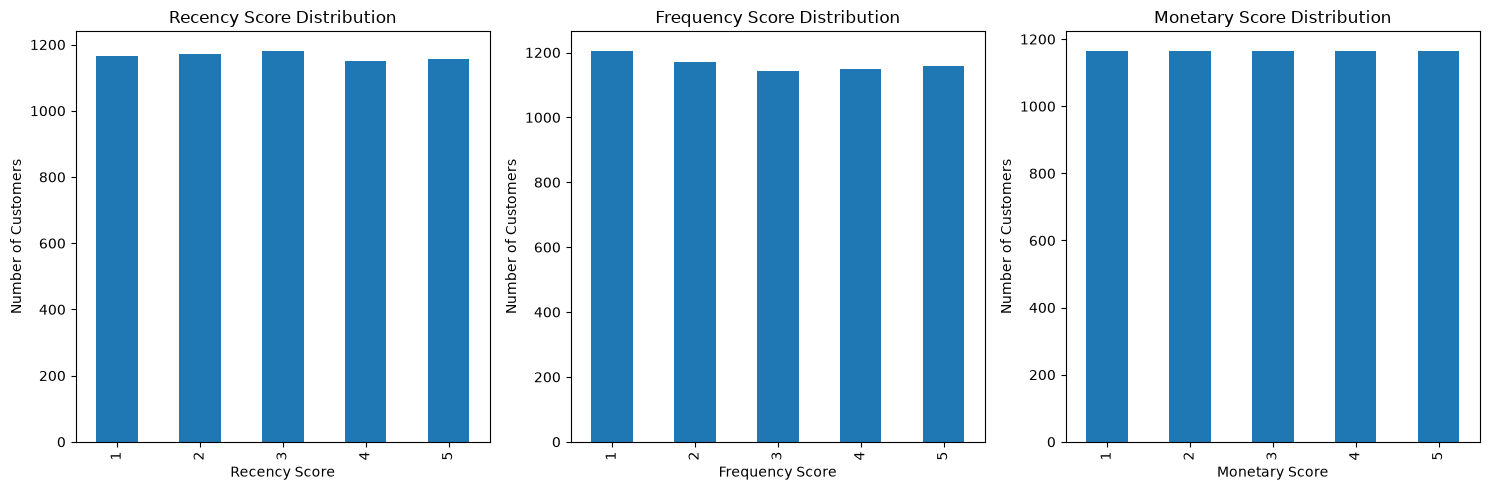

In [28]:
# Make bar plot for user group distribution for Recency, Frequency, and Monetary scores.

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df_rfm['Recency_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Recency Score Distribution')
plt.xlabel('Recency Score')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
df_rfm['Frequency_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Frequency Score Distribution')
plt.xlabel('Frequency Score')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
df_rfm['Monetary_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Monetary Score Distribution')
plt.xlabel('Monetary Score')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Heatmap of Monetary Score by Recency and Frequency

The heatmap summarizes the average Monetary score for combinations of Recency and Frequency groups. This visualization helps identify which time-and-frequency segments are associated with higher spending.


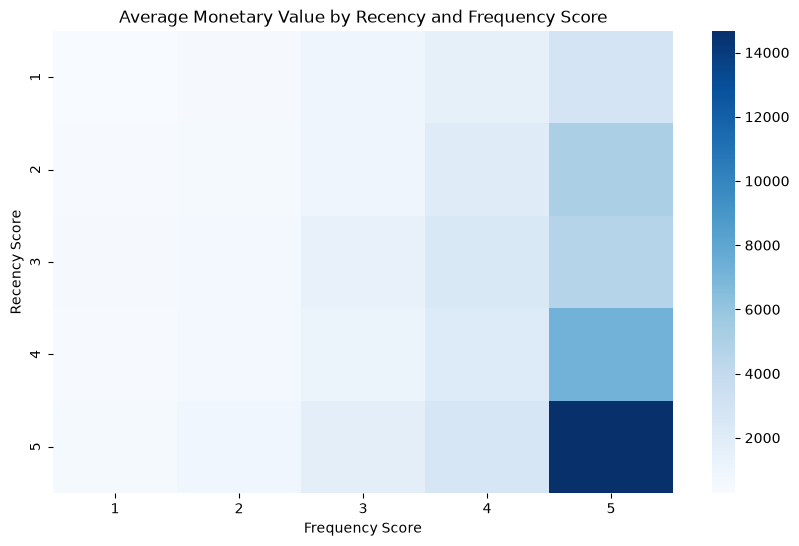

In [29]:
# As per the instructions, create a heatmap for the Recency group by the Frequency group.
# The cell contents are the average Monetary values for each Recency/Frequency score combination.

plt.figure(figsize=(10, 6))
heatmap_data = df_rfm.pivot_table(index='Recency_score', columns='Frequency_score', values='Monetary', aggfunc='mean')
cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(heatmap_data, annot=False, fmt='.0f', cmap=cmap)
plt.title('Average Monetary Value by Recency and Frequency Score')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.show()


### Identify Customers with the Highest RFM Score

This cell isolates customers with an RFM score of `555`, meaning they are in the highest score group for Recency, Frequency, and Monetary value. These customers represent the strongest segment under the scoring method used here.


In [30]:
"""

For the customers with the RFM Score of 555, generate a boxplot of the transaction amount by the customers’ residence countries. 
Which countries have the highest median transaction amount? 
Which countries have relatively large variations in the transaction amount?

"""

# Identify customers with RFM Score of 555
customers_555 = df_rfm[df_rfm['RFM_Score'] == 555]['Customer ID']

# Inspect the results to see which customers have RFM Score of 555
customers_555.head()

2     12349.0
12    12359.0
15    12362.0
32    12380.0
46    12395.0
Name: Customer ID, dtype: float64

### Boxplot of Transaction Amount by Country for Top RFM Customers

This visualization compares transaction amount distributions by customer country for customers with an RFM score of `555`. Boxplots are useful here because they show medians, spread, and potential outliers across countries.


<Figure size 1200x1000 with 0 Axes>

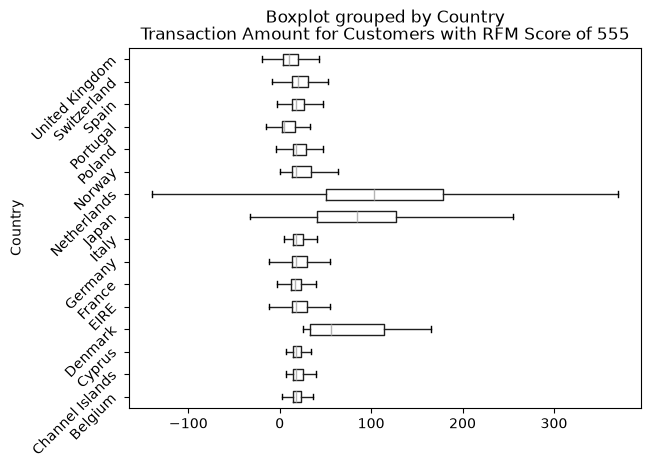

In [31]:
# Generate the boxplot of the transaction amount by the customers’ residence countries for customers with RFM Score of 555.

# Find these transactions in the original dataset and create a new dataframe for these transactions.
df_transaction_555 = df_part2[df_part2['Customer ID'].isin(customers_555)]

# Make the boxplot of the transaction amount by the customers’ residence countries for customers with RFM Score of 555.

plt.figure(figsize=(12, 10))
df_transaction_555.boxplot(column='AmountSpent', by='Country', grid=False, rot=45, vert=False, showfliers=False)
plt.title('Transaction Amount for Customers with RFM Score of 555')
plt.show()

### Alternative Seaborn Visualization

This cell provides an alternative plotting approach using Seaborn. Seaborn can produce cleaner statistical graphics with less manual formatting than base Matplotlib.


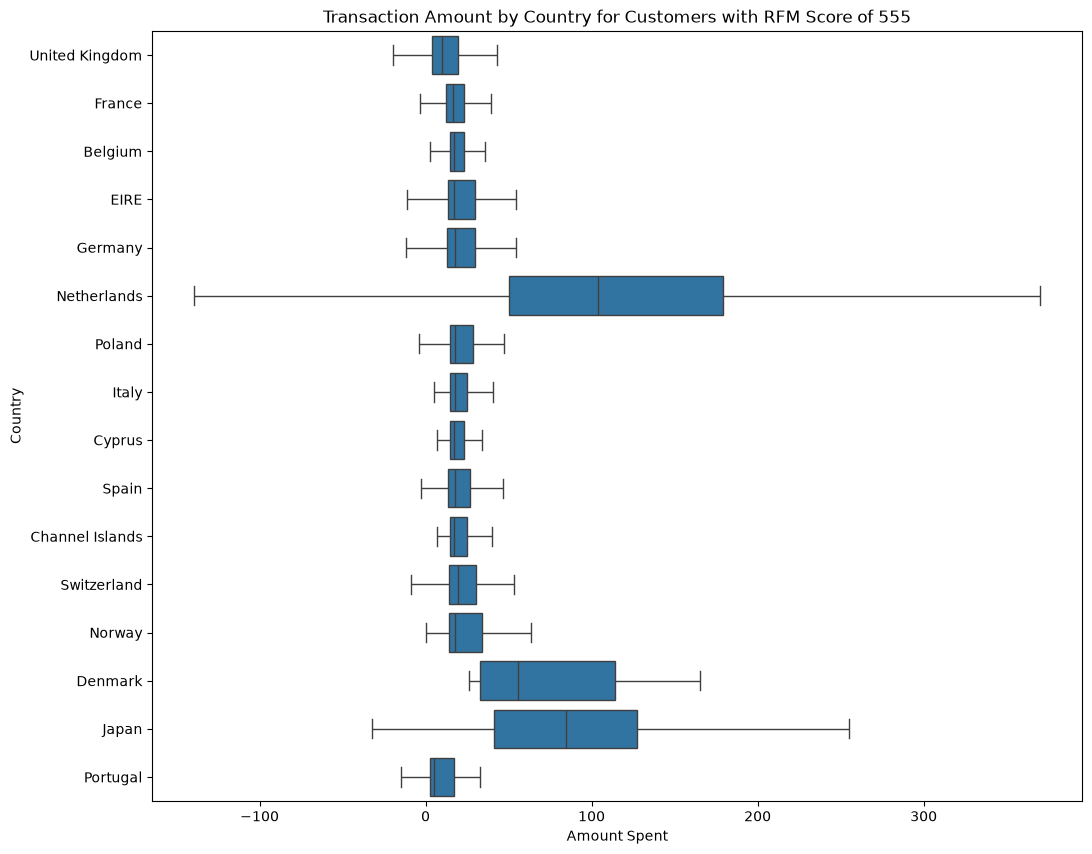

In [32]:
# Alternative way of using seaborn

plt.figure(figsize=(12, 10))

sns.boxplot(
    data=df_transaction_555,
    x='AmountSpent',
    y='Country',
    showfliers=False
)

plt.title('Transaction Amount by Country for Customers with RFM Score of 555')
plt.xlabel('Amount Spent')
plt.ylabel('Country')
plt.show()

## A Quick Recap:

The notebook demonstrates two common data analysis workflows:

- Choosing a reasonable histogram bin width for continuous numerical data.
- Transforming transaction-level data into customer-level RFM segments.

In both parts, the most important pattern is to inspect intermediate results before relying on the final visualization or score. This helps catch issues such as incorrect bin boundaries, missing customer IDs, negative transaction values, or unexpected merge behavior.
